In [23]:
import numpy as np
import itertools
import functools
from numpy import random as random
import jax
import jax.numpy as jnp

from functools import partial
from scipy.io import loadmat

import matplotlib as mpl
from matplotlib import pyplot as plt

import pickle as pkl

from scipy.signal import fftconvolve
from scipy.ndimage import gaussian_filter1d

In [89]:
rng = np.random.default_rng()

In [76]:
movieBinnedSpiking = loadmat('../Data/movieBinnedSpiking.mat')

In [3]:
movnames = movieBinnedSpiking['movnames']
ncell = movieBinnedSpiking['ncell']
nmov = movieBinnedSpiking['nmov']
nreps = movieBinnedSpiking['nreps'].flatten()
samplingFreq = movieBinnedSpiking['samplingFreq']
binned = movieBinnedSpiking['binned']

In [94]:
mov1 = jnp.array(binned[1:nreps[0],:,np.random.randint(0,93,20),0]).reshape((-1,20))

In [96]:
mov1_corr = jnp.corrcoef(mov1.T)

C:\Users\alber\AppData\Local\Temp\ipykernel_10200\2912842667.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


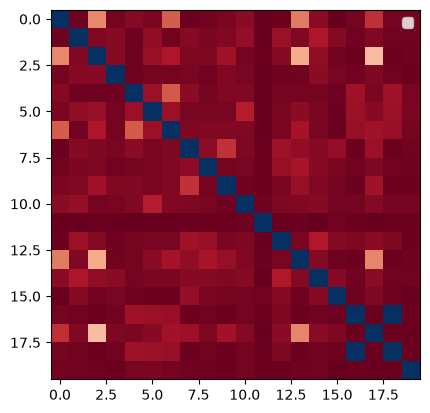

In [104]:
plt.imshow(mov1_corr,cmap='RdBu')
plt.legend()

Text(0, 0.5, '<firing rate> (spikes/s)')

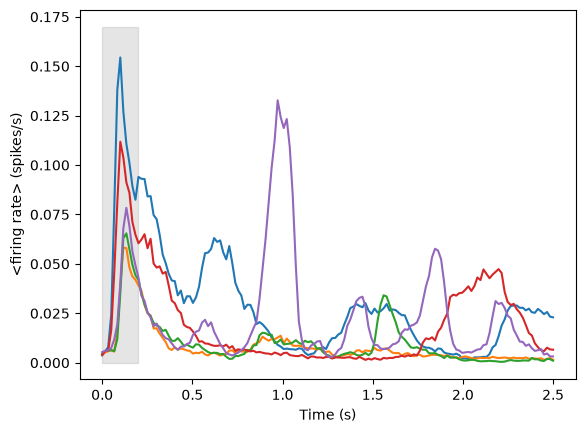

In [64]:
fig,ax = plt.subplots(1,1)

for i in range(5):
    mov = binned[1:nreps[i],:,:,i].mean(axis=0).mean(axis=1)
    m_ = mov[:150]
    m_fr = gaussian_filter1d(m_,sigma=0.5)
    ax.plot(np.linspace(0,2.5,m_fr.shape[0]),m_fr)
ax.fill_betweenx(np.linspace(0,0.17,5),0,0.2,color='grey',alpha=0.2)
ax.set_xlabel('Time (s)')
ax.set_ylabel('<firing rate> (spikes/s)')

In [ ]:
fig,ax = plt.subplots(1,1)

for i in range(5):
    mov = binned[1:nreps[i],:,:,i].mean(axis=0).mean(axis=1)
    m_ = mov[:150]
    m_fr = gaussian_filter1d(m_,sigma=0.5)
    ax.plot(np.linspace(0,2.5,m_fr.shape[0]),m_fr)